# Make STEP from Profile (prototyping notebook)

This notebook is the original prototyping workflow. For production use, prefer the
packaged API or CLI:

- Python: `from lantern_step import load_profile, build_taper_model, make_solid,
  export_step, build_reference_bodies`
- CLI: `lantern-step-cli INPUT.xlsx -o OUT.step --start 5 --end 65 --final-d 1.2`

The cells below remain a self-contained reference implementation.

In [1]:
import pandas as pd
import cadquery as cq
from cadquery import exporters
from scipy.interpolate import make_interp_spline
import numpy as np
import matplotlib.pyplot as plt

base_folder="/Users/chrisbetters/Library/CloudStorage/OneDrive-TheUniversityofSydney(Staff)/SAIL-Nexus/Lantern Fabrication/Lantern Data/"
lantern_uuid="PL-250422-02-1310-03"
datafile=base_folder+"/"+lantern_uuid+"/"+lantern_uuid+"_profile.xlsx"
datafile='/Users/chrisbetters/Library/CloudStorage/OneDrive-TheUniversityofSydney(Staff)/SAIL-Nexus/Lantern Fabrication/Lantern Data/PL-250422-02-1310-03/PL-250422-02-1310-03_profile_orig.xlsx'

datafile

'/Users/chrisbetters/Library/CloudStorage/OneDrive-TheUniversityofSydney(Staff)/SAIL-Nexus/Lantern Fabrication/Lantern Data/PL-250422-02-1310-03/PL-250422-02-1310-03_profile_orig.xlsx'

#### Step 1: Load and Process Data
------------------------------

In [3]:
# Load the data from Excel
df = pd.read_excel(datafile, sheet_name=0)
# Select relevant columns and drop missing values
df = df[['Left Z Motor  - Bottom Camera', 
         'Fiber Diameter - Bottom Camera', 
         'Fiber Diameter - Side Camera']].dropna()
df.columns = ['Z', 'Diameter_X', 'Diameter_Y']
# Normalize Z so that it starts at 0 (µm)
df['Z'] = df['Z'] - df['Z'].min()

# Compute the average diameter and corresponding radius (in µm)
df['Diameter'] = (df['Diameter_X'] + df['Diameter_Y']) / 2
df['Radius'] = df['Diameter'] / 2

# Convert units from µm to mm (1 µm = 1e-3 mm)
z_raw = df['Z'].values * 1e-3     # Z in mm
r_raw = df['Radius'].values * 1e-3  # Radius in mm

#### Step 2: Apply Cubic Spline Smoothing
-------------------------------------------

In [4]:
spline = make_interp_spline(z_raw, r_raw, k=3)
num_points = 100  # resolution of the smoothed profile
z_smooth = np.linspace(z_raw.min(), z_raw.max(), num_points)
r_smooth = spline(z_smooth)

#### Step 3: Define Model Range Based on Distance from Start
------------------------------------------------------

In [5]:
# User-defined start and end distances (in mm)
start_distance = 1 # Modify as needed
end_distance = z_raw.max()   # Modify as needed (e.g., 20.0)

# Filter the smoothed data based on the specified range
mask = (z_smooth >= start_distance) & (z_smooth <= end_distance)
z_model = z_smooth[mask]
r_model = r_smooth[mask]

#### Step 4: Extrapolate Final Measurement with Intermediate Points
------------------------------------------------------

In [ ]:
# Desired final diameter is 1.75 mm, so final radius is:
radius_final = 1.75 / 2  # 0.875 mm

# Use the last 10 mm of data for a linear fit to extrapolate
if z_model[-1] - 1 < z_model[0]:
    idx = np.arange(len(z_model))
else:
    idx = np.where(z_model >= (z_model[-1] - 1))[0]

# Linear regression: r = m*z + b
m, b = np.polyfit(z_model[idx], r_model[idx], 1)

# Calculate the extrapolated Z position for the final radius
if np.abs(m) < 1e-6:
    z_extrapolated = z_model[-1]
else:
    z_extrapolated = (radius_final - b) / m
z_extrapolated = max(z_extrapolated, z_model[-1])  # ensure it doesn't go backwards

# Generate several intermediate points between the last measured point and the extrapolated point
num_extrap_points = 100  # number of intermediate points
z_extrap_points = np.linspace(z_model[-1], z_extrapolated, num_extrap_points + 1)[1:]  # skip duplicate
r_extrap_points = np.linspace(r_model[-1], radius_final, num_extrap_points + 1)[1:]     # skip duplicate

# Extend the model arrays with the extrapolation points
z_model_extended = np.concatenate([z_model, z_extrap_points])
r_model_extended = np.concatenate([r_model, r_extrap_points])

# Guard against spline overshoot producing non-physical (<= 0) radii.
# Floor at 1 µm (1e-3 mm) so every profile point is a valid radius.
r_model_extended = np.clip(r_model_extended, 1e-3, None)


#### Step 5: Build a Single Closed Profile and Revolve It Into a Solid
------------------------------------------------------

In [ ]:
# Build the entire part as ONE closed (radius, z) profile and revolve it 360
# degrees about the central (Z) axis. A surface of revolution from a closed
# face is always a single watertight solid, which avoids the previous
# loft + boolean-fuse approach whose coincident-face union could silently
# leave open shells (which import as surfaces, not a solid).
extension_length = 13  # mm, constant-radius cylinder at the end
z_cyl_end = z_extrapolated + extension_length  # end of cylinder (mm)

# Profile on the XZ workplane: local (x, y) = (radius, z)
profile_pts = [(0.0, z_model_extended[0])]                       # on axis -> flat start cap
profile_pts += [(float(r), float(z))                             # tapered wall
                for z, r in zip(z_model_extended, r_model_extended)]
profile_pts.append((radius_final, z_cyl_end))                    # constant-radius cylinder wall
profile_pts.append((0.0, z_cyl_end))                             # flat end cap back to axis

# .close() returns along the axis to the first point, closing the profile.
# Revolve about the Z axis (the local Y axis of the XZ workplane).
solid_combined = (
    cq.Workplane("XZ")
    .polyline(profile_pts)
    .close()
    .revolve(360, (0, 0, 0), (0, 1, 0))
    .val()
)

#### Step 6: Verify the Result Is a Single Watertight Solid
------------------------------------------------------
The constant-radius cylinder extension is now part of the revolved profile
above, so no separate body or boolean union is required.

In [ ]:
# Confirm we have exactly one valid, closed solid before exporting.
from OCP.BRepCheck import BRepCheck_Analyzer
print("Shape type:", solid_combined.wrapped.ShapeType())
print("Solids:", len(solid_combined.Solids()), " Shells:", len(solid_combined.Shells()))
print("Valid:", BRepCheck_Analyzer(solid_combined.wrapped).IsValid())
print(f"Volume: {solid_combined.Volume():.3f} mm^3")

#### Step 6b (optional): Embed Reference Planes
------------------------------------------------------
Flat disks normal to the taper axis, bundled into the STEP as separate surface bodies (the solid is never modified). Specify stations by target diameter and/or by axial position; leave the lists empty to export the solid alone. In SolidWorks each disk imports as a surface you can convert to a reference plane or section against.

In [ ]:
# Specify reference stations (leave empty for none)
ref_diameters = []   # e.g. [1.2, 0.5]  -> planes where the taper hits these diameters (mm)
ref_positions = []   # e.g. [10, 30]    -> planes at these axial positions z (mm)


def solve_z_for_diameter(z_arr, r_arr, target_d):
    """z positions where the local diameter crosses target_d (taper only)."""
    target_r = target_d / 2.0
    g = np.asarray(r_arr) - target_r
    zs = []
    for i in range(len(g) - 1):
        a, b = g[i], g[i + 1]
        if a == 0.0:
            zs.append(float(z_arr[i]))
        elif a * b < 0:
            t = a / (a - b)
            zs.append(float(z_arr[i] + t * (z_arr[i + 1] - z_arr[i])))
    if len(g) and g[-1] == 0.0:
        zs.append(float(z_arr[-1]))
    out = []
    for z in sorted(zs):
        if not out or abs(z - out[-1]) > 1e-3:
            out.append(z)
    return out


def make_reference_disk(z, local_r):
    """Circular planar face (a free surface body) normal to the Z axis at z."""
    margin = max(0.5, 0.25 * local_r)  # mm beyond the wall, for selectability
    wire = cq.Wire.makeCircle(local_r + margin, cq.Vector(0, 0, z), cq.Vector(0, 0, 1))
    return cq.Face.makeFromWires(wire)


z_full = np.concatenate([z_model_extended, [z_cyl_end]])
r_full = np.concatenate([r_model_extended, [radius_final]])

ref_bodies = []
for d in ref_diameters:
    for zc in solve_z_for_diameter(z_model_extended, r_model_extended, d):
        lr = float(np.interp(zc, z_full, r_full))
        ref_bodies.append(make_reference_disk(zc, lr))
        print(f'reference plane: diameter {d:.3f} mm at z = {zc:.2f} mm')
for zc in ref_positions:
    if z_full[0] <= zc <= z_full[-1]:
        lr = float(np.interp(zc, z_full, r_full))
        ref_bodies.append(make_reference_disk(zc, lr))
        print(f'reference plane: z = {zc:.2f} mm (diameter {2*lr:.3f} mm)')
    else:
        print(f'reference plane: z = {zc:.2f} mm is outside the part - skipped')

export_shape = (
    cq.Compound.makeCompound([solid_combined] + ref_bodies)
    if ref_bodies else solid_combined
)

#### Step 7: Export the Final Solid as a STEP File
------------------------------------------------------

In [ ]:
filepath=datafile=base_folder+"/"+lantern_uuid+"/"+lantern_uuid+"_model.step"

exporters.export(export_shape, filepath)
print(f"STEP file saved as {filepath}")

#### Step 7: Plot the Smoothed Diameter vs. Z
------------------------------------------------------

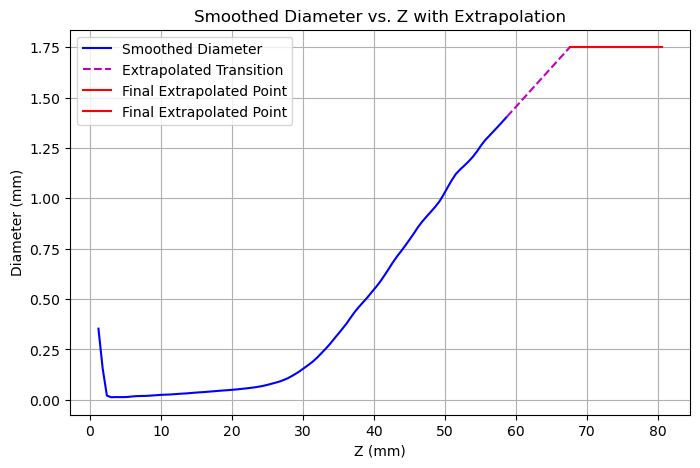

In [10]:
plt.figure(figsize=(8, 5))
# Plot the smoothed diameter (2*r) vs. Z for the original data
plt.plot(z_model, 2 * r_model, 'b-', label='Smoothed Diameter')
# Plot the extrapolated section with intermediate points
plt.plot(z_extrap_points, 2 * r_extrap_points, 'm--', label='Extrapolated Transition')
# Mark the final extrapolated pointx
plt.plot(z_extrapolated, 2 * radius_final, 'r-', label='Final Extrapolated Point')
# add cylinder
plt.plot(np.linspace(z_extrapolated,z_extrapolated+extension_length,10), np.ones(10)*2 * radius_final, 'r-', label='Final Extrapolated Point')

plt.xlabel("Z (mm)")
plt.ylabel("Diameter (mm)")
plt.title("Smoothed Diameter vs. Z with Extrapolation")
plt.legend()
plt.grid(True)
plt.show()
solid_combined